Fitted  w_mu=0.0319  b_mu=0.0100  gamma=0.5954
Test ECE  before=0.28492  after=0.11194
Mean FD   before=141.86812  after=17.72979


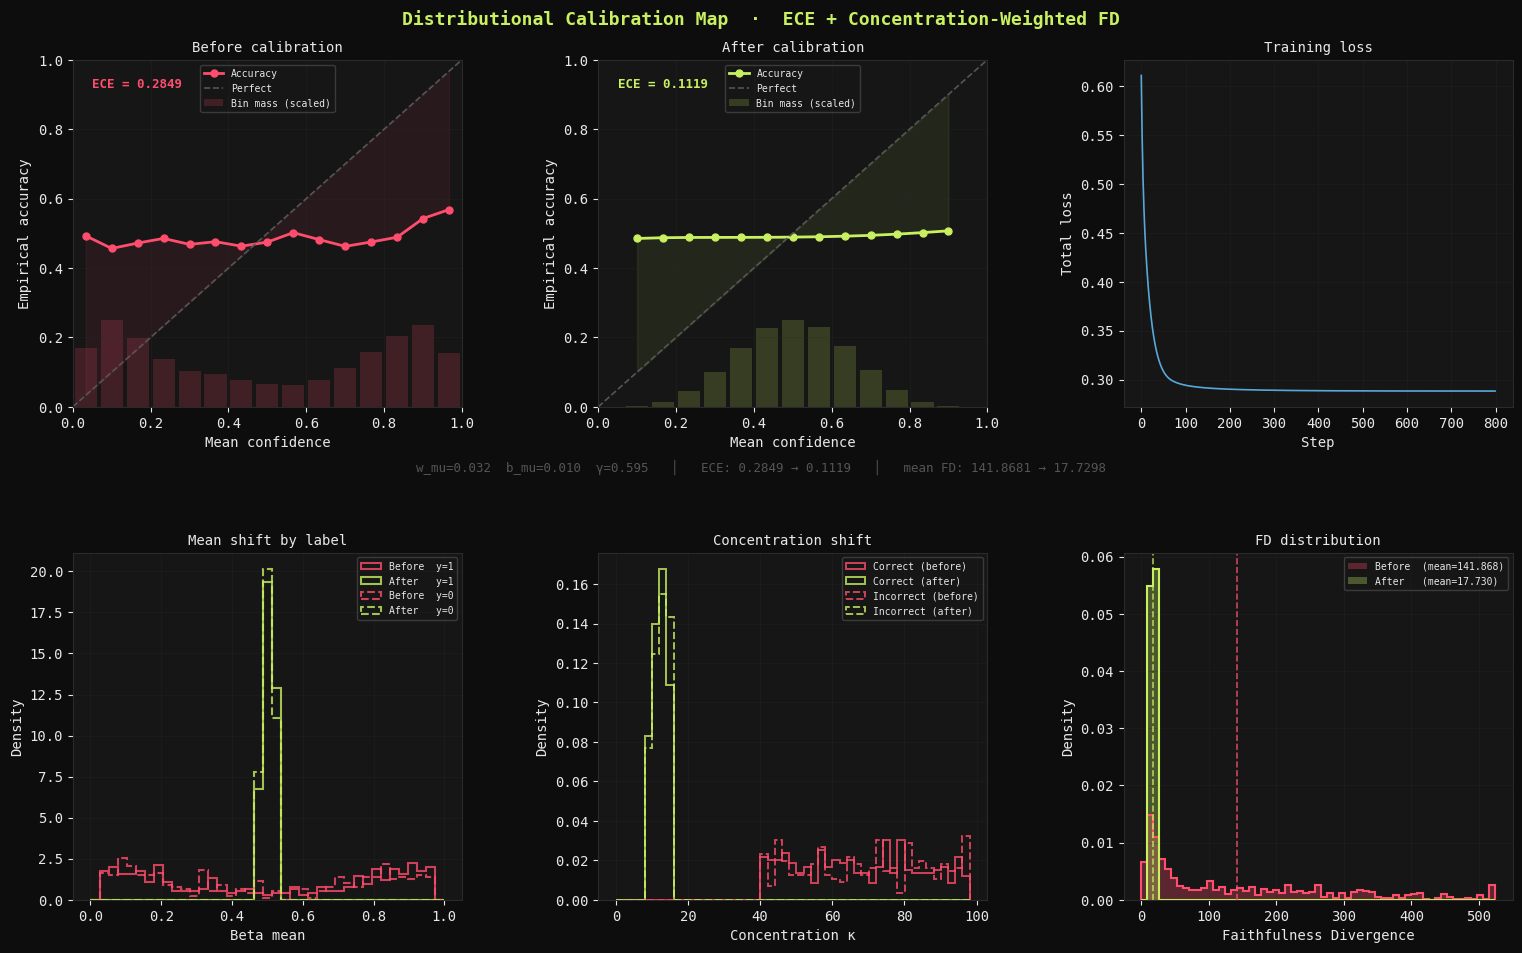

In [13]:
"""
Distributional Confidence Calibration Map
Minimises soft-binned ECE (Wang 2025) + concentration-weighted mean loss (FD-inspired).

Map:
  mu'  = sigmoid(softplus(w) * logit(mu) + b)   # monotonic Platt scaling
  kap' = kap ^ exp(log_gamma)                    # global concentration power
  a'   = mu' * kap',  b' = (1 - mu') * kap'

Loss:
  L = ECE_soft + lambda * sum_i [ kap'_i * (mu'_i - y_i)^2 ] / sum_i kap'_i
"""

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import beta as scipy_beta
from scipy.special import betainc as scipy_betainc


# differentiable regularised incomplete beta via torch custom op
# gradient through a, b approximated by finite diff over scipy;
# gradient through x is computed analytically.
class BetaIncFunc(torch.autograd.Function):
    @staticmethod
    def forward(ctx, a, b, x):
        ctx.save_for_backward(a, b, x)
        out = torch.from_numpy(
            scipy_betainc(a.detach().numpy(), b.detach().numpy(),
                          x.detach().numpy()).astype(np.float32))
        return out

    @staticmethod
    def backward(ctx, grad_output):
        a, b, x = ctx.saved_tensors
        # dI/dx = x^(a-1)*(1-x)^(b-1) / B(a,b)   (Beta pdf)
        log_pdf = ((a - 1) * torch.log(x.clamp(1e-9))
                 + (b - 1) * torch.log((1 - x).clamp(1e-9))
                 - torch.lgamma(a) - torch.lgamma(b)
                 + torch.lgamma(a + b))
        grad_x = grad_output * torch.exp(log_pdf)

        # finite-diff gradients w.r.t. a and b (small eps, cheaper than autograd)
        eps = 1e-4
        a_np, b_np, x_np = a.numpy(), b.numpy(), x.numpy()
        da = torch.from_numpy(((scipy_betainc(a_np + eps, b_np, x_np)
                               - scipy_betainc(a_np - eps, b_np, x_np))
                               / (2 * eps)).astype(np.float32))
        db = torch.from_numpy(((scipy_betainc(a_np, b_np + eps, x_np)
                               - scipy_betainc(a_np, b_np - eps, x_np))
                               / (2 * eps)).astype(np.float32))
        return grad_output * da, grad_output * db, grad_x


def betainc(a, b, x):
    """Differentiable regularised incomplete beta I_x(a, b)."""
    x = x.expand_as(a)
    return BetaIncFunc.apply(a, b, x)


# ── reproducibility ──────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)


# ════════════════════════════════════════════════════════════════════════════
# 1. SYNTHETIC DATA GENERATION
# ════════════════════════════════════════════════════════════════════════════

def generate_data(N=2000):
    """
    Synthetic data with ECE ~ 0.30 and a flat reliability diagram.

    The model is confidently wrong: confidence is bimodal at ~0.2 and ~0.8,
    but labels are drawn from an independent symmetric Beta(2,2) prior.
    So every confidence bin has ~50% accuracy regardless of confidence level.
    The reliability curve is flat around 0.5 while the confidence mass sits
    far from 0.5, producing high ECE (~0.31) with no diagonal trend.
    """
    alphas, betas, ys = [], [], []

    for _ in range(N):
        # label from symmetric prior, independent of model confidence
        p_true = np.random.beta(2.0, 2.0)

        # bimodal confidence: model is either confidently low or confidently high
        # but in a direction uncorrelated with the true label
        if np.random.rand() < 0.5:
            mu_model = np.random.beta(1.5, 6.0)   # peaks around 0.2
        else:
            mu_model = np.random.beta(6.0, 1.5)   # peaks around 0.8
        mu_model = np.clip(mu_model, 0.05, 0.95)

        # high concentration: model is sharp but wrong
        kap = np.random.uniform(40, 100)

        a = mu_model * kap
        b = (1 - mu_model) * kap

        y = float(np.random.binomial(1, p_true))

        alphas.append(a)
        betas.append(b)
        ys.append(y)

    alphas = np.array(alphas, dtype=np.float32)
    betas  = np.array(betas,  dtype=np.float32)
    ys     = np.array(ys,     dtype=np.float32)
    return alphas, betas, ys


alphas, betas, ys = generate_data(N=2000)

# train / test split (70 / 30)
N_train = int(0.7 * len(ys))
idx = np.random.permutation(len(ys))
tr, te = idx[:N_train], idx[N_train:]

a_tr = torch.tensor(alphas[tr]); b_tr = torch.tensor(betas[tr]); y_tr = torch.tensor(ys[tr])
a_te = torch.tensor(alphas[te]); b_te = torch.tensor(betas[te]); y_te = torch.tensor(ys[te])


# ════════════════════════════════════════════════════════════════════════════
# 2. SOFT-BINNED ECE  (Wang 2025 / distributional generalisation)
# ════════════════════════════════════════════════════════════════════════════

def soft_ece(a, b, y, M=15):
    """
    Soft-binned squared ECE.
    Each sample contributes to bin m with weight P(S in I_m | a, b)
    computed via the Beta CDF.  Midpoint approximation for g_m.
    """
    edges = torch.linspace(0.0, 1.0, M + 1)
    mids  = 0.5 * (edges[1:] + edges[:-1])          # [M]

    # CDF weights  [N, M]
    F_hi = betainc(a[:,None].expand(-1,M), b[:,None].expand(-1,M), edges[1:].clamp(1e-6,1-1e-6).unsqueeze(0).expand(a.shape[0],-1))
    F_lo = betainc(a[:,None].expand(-1,M), b[:,None].expand(-1,M), edges[:-1].clamp(1e-6,1-1e-6).unsqueeze(0).expand(a.shape[0],-1))
    w    = (F_hi - F_lo).clamp(min=0)               # [N, M]

    denom = w.sum(0).clamp(min=1e-8)
    r_m   = (w * y[:, None]).sum(0) / denom          # empirical accuracy per bin
    p_m   = w.mean(0)                                # bin mass

    ece = (p_m * (r_m - mids).pow(2)).sum()
    return ece


# ════════════════════════════════════════════════════════════════════════════
# 3. LEARNED MAP
# ════════════════════════════════════════════════════════════════════════════

def apply_map(params, a, b):
    w_raw, b_mu, log_gamma = params
    w_mu = F.softplus(w_raw)                         # > 0  → monotonic

    mu  = a / (a + b)
    kap = a + b

    mu_logit = torch.logit(mu.clamp(1e-4, 1 - 1e-4))
    mu_p     = torch.sigmoid(w_mu * mu_logit + b_mu) # monotonic Platt scaling
    kap_p    = kap.pow(torch.exp(log_gamma))          # global concentration power

    a2 = mu_p * kap_p
    b2 = (1 - mu_p) * kap_p
    return a2, b2, mu_p, kap_p


def beta_kl(a1, b1, a0, b0):
    """KL( Beta(a1,b1) || Beta(a0,b0) ) -- closed form."""
    return (torch.lgamma(a0 + b0) - torch.lgamma(a0) - torch.lgamma(b0)
          - torch.lgamma(a1 + b1) + torch.lgamma(a1) + torch.lgamma(b1)
          + (a1 - a0) * torch.digamma(a1)
          + (b1 - b0) * torch.digamma(b1)
          + (a0 - a1 + b0 - b1) * torch.digamma(a1 + b1))

def total_loss(params, a, b, y, lam_mean=1.0, lam_fd=0.001, M=15):
    a2, b2, mu_p, kap_p = apply_map(params, a, b)

    # population ECE
    ece = soft_ece(a2, b2, y, M=M)

    # instance-level: kappa-weighted mean loss
    # wrong-and-sharp -> penalised more; wrong-and-wide -> penalised less
    weighted_sq = kap_p * (mu_p - y).pow(2)
    mean_loss   = weighted_sq.sum() / kap_p.sum()    # normalised

    # FD: (a+b) * KL(post || prior) -- penalises overconfident wrong predictions
    # and controls concentration from inflating unchecked
    a1 = a2 + y
    b1 = b2 + (1 - y)
    kl_fd  = beta_kl(a2, b2, a1, b1)               # KL(post || prior) >= 0
    fd_loss = ((a2 + b2) * kl_fd).mean()

    return ece + lam_mean * mean_loss + lam_fd * fd_loss


# ════════════════════════════════════════════════════════════════════════════
# 4. TRAINING
# ════════════════════════════════════════════════════════════════════════════

params = [
    torch.tensor(0.5,  requires_grad=True),   # w_raw  (softplus → w_mu > 0)
    torch.tensor(0.0,  requires_grad=True),   # b_mu
    torch.tensor(0.0,  requires_grad=True),   # log_gamma
]

optimiser = torch.optim.Adam(params, lr=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=800)

losses = []
for step in range(800):
    optimiser.zero_grad()
    L = total_loss(params, a_tr, b_tr, y_tr, lam_mean=1.0, lam_fd=0.001, M=15)
    L.backward()
    optimiser.step()
    scheduler.step()
    losses.append(L.item())

w_mu_fit    = F.softplus(params[0]).item()
b_mu_fit    = params[1].item()
gamma_fit   = torch.exp(params[2]).item()

print(f"Fitted  w_mu={w_mu_fit:.4f}  b_mu={b_mu_fit:.4f}  gamma={gamma_fit:.4f}")


# ════════════════════════════════════════════════════════════════════════════
# 5. TEST-SET EVALUATION
# ════════════════════════════════════════════════════════════════════════════

with torch.no_grad():
    a2_te, b2_te, mu_p_te, kap_p_te = apply_map(params, a_te, b_te)

def compute_ece_scalar(a, b, y, M=15):
    """Absolute ECE (Wang soft-bin, L1) for reporting."""
    edges = torch.linspace(0.0, 1.0, M + 1)
    mids  = 0.5 * (edges[1:] + edges[:-1])
    F_hi = betainc(a[:,None].expand(-1,M), b[:,None].expand(-1,M),
                   edges[1:].clamp(1e-6,1-1e-6).unsqueeze(0).expand(a.shape[0],-1))
    F_lo = betainc(a[:,None].expand(-1,M), b[:,None].expand(-1,M),
                   edges[:-1].clamp(1e-6,1-1e-6).unsqueeze(0).expand(a.shape[0],-1))
    w     = (F_hi - F_lo).clamp(min=0)
    denom = w.sum(0).clamp(min=1e-8)
    r_m   = (w * y[:, None]).sum(0) / denom
    p_m   = w.mean(0)
    return (p_m * (r_m - mids).abs()).sum().item()

ece_before = compute_ece_scalar(a_te, b_te, y_te)
ece_after  = compute_ece_scalar(a2_te, b2_te, y_te)
print(f"Test ECE  before={ece_before:.5f}  after={ece_after:.5f}")


# ════════════════════════════════════════════════════════════════════════════
# 5b. FAITHFULNESS DIVERGENCE  (instance-level)
#     FD_i = (a + b) * KL( Beta_post || Beta_prior )
#     where Beta_post is the single Bayesian update by label y_i:
#       y=1 -> post = Beta(a+1, b),  y=0 -> post = Beta(a, b+1)
#     KL(Beta(a1,b1) || Beta(a0,b0)) in closed form via lgamma / digamma.
# ════════════════════════════════════════════════════════════════════════════


def faithfulness_divergence(a, b, y):
    """
    Per-instance FD = (a + b) * KL(Beta_post || Beta_prior).
    Beta_post: Beta(a+y, b+1-y)  -- single Bayesian update by label
    Beta_prior: Beta(a, b)
    KL(P||Q): pass P as (a1,b1) and Q as (a0,b0).
    Note: beta_kl(a1,b1,a0,b0) computes KL(Q||P) due to sign convention,
    so we pass (prior, post) to get KL(post||prior) >= 0.
    """
    a1 = a + y          # posterior alpha
    b1 = b + (1 - y)    # posterior beta
    kl = beta_kl(a, b, a1, b1)   # beta_kl(a0,b0,a1,b1) = KL(post||prior)
    fd = (a + b) * kl
    return fd


with torch.no_grad():
    fd_before = faithfulness_divergence(a_te, b_te, y_te)
    fd_after  = faithfulness_divergence(a2_te, b2_te, y_te)

fd_mean_before = fd_before.mean().item()
fd_mean_after  = fd_after.mean().item()
print(f"Mean FD   before={fd_mean_before:.5f}  after={fd_mean_after:.5f}")


# ════════════════════════════════════════════════════════════════════════════
# 6. RELIABILITY DIAGRAM  (Wang soft-bin version)
# ════════════════════════════════════════════════════════════════════════════

def reliability_data(a, b, y, M=15):
    """Return (bin_midpoints, r_m, p_m) for plotting."""
    edges = torch.linspace(0.0, 1.0, M + 1)
    mids  = 0.5 * (edges[1:] + edges[:-1])
    F_hi = betainc(a[:,None].expand(-1,M), b[:,None].expand(-1,M), edges[1:].clamp(1e-6,1-1e-6).unsqueeze(0).expand(a.shape[0],-1))
    F_lo = betainc(a[:,None].expand(-1,M), b[:,None].expand(-1,M), edges[:-1].clamp(1e-6,1-1e-6).unsqueeze(0).expand(a.shape[0],-1))
    w    = (F_hi - F_lo).clamp(min=0)
    denom = w.sum(0).clamp(min=1e-8)
    r_m   = (w * y[:, None]).sum(0) / denom
    p_m   = w.mean(0)
    return mids.numpy(), r_m.numpy(), p_m.numpy()

with torch.no_grad():
    mids_b, rm_b, pm_b = reliability_data(a_te, b_te, y_te)
    mids_a, rm_a, pm_a = reliability_data(a2_te, b2_te, y_te)

mu_before = (a_te / (a_te + b_te)).numpy()
mu_after  = mu_p_te.numpy()
kap_before = (a_te + b_te).numpy()
kap_after  = kap_p_te.numpy()


# ════════════════════════════════════════════════════════════════════════════
# 7. PLOTTING
# ════════════════════════════════════════════════════════════════════════════

DARK   = "#0d0d0d"
PANEL  = "#161616"
BORDER = "#2a2a2a"
ACCENT = "#c8f060"    # lime
RED    = "#ff4d6d"
BLUE   = "#60b8f0"
MUTED  = "#555555"
WHITE  = "#e8e8e8"

plt.rcParams.update({
    "figure.facecolor":  DARK,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    BORDER,
    "axes.labelcolor":   WHITE,
    "xtick.color":       WHITE,
    "ytick.color":       WHITE,
    "text.color":        WHITE,
    "grid.color":        BORDER,
    "grid.linewidth":    0.6,
    "font.family":       "monospace",
    "font.size":         10,
})

fig = plt.figure(figsize=(16, 10), facecolor=DARK)
fig.suptitle(
    "Distributional Calibration Map  ·  ECE + Concentration-Weighted FD",
    fontsize=13, color=ACCENT, y=0.97, fontfamily="monospace", fontweight="bold"
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35,
                       left=0.07, right=0.97, top=0.92, bottom=0.08)

# ── helper: reliability diagram ──────────────────────────────────────────
def plot_reliability(ax, mids, r_m, p_m, title, ece_val, colour):
    bar_w = mids[1] - mids[0]
    ax.bar(mids, p_m / p_m.max() * 0.25, width=bar_w * 0.85,
           bottom=0, color=colour, alpha=0.18, label="Bin mass (scaled)")
    mask = p_m > 1e-4
    ax.plot(mids[mask], r_m[mask], "o-", color=colour, lw=2, ms=5, label="Accuracy")
    ax.plot([0, 1], [0, 1], "--", color=MUTED, lw=1.2, label="Perfect")
    ax.fill_between(mids[mask], mids[mask], r_m[mask],
                    color=colour, alpha=0.08)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Mean confidence"); ax.set_ylabel("Empirical accuracy")
    ax.set_title(title, color=WHITE, fontsize=10)
    ax.text(0.05, 0.92, f"ECE = {ece_val:.4f}", transform=ax.transAxes,
            color=colour, fontsize=9, fontweight="bold")
    ax.legend(fontsize=7, framealpha=0.2)
    ax.grid(True, alpha=0.3)

ax0 = fig.add_subplot(gs[0, 0])
plot_reliability(ax0, mids_b, rm_b, pm_b, "Before calibration", ece_before, RED)

ax1 = fig.add_subplot(gs[0, 1])
plot_reliability(ax1, mids_a, rm_a, pm_a, "After calibration",  ece_after,  ACCENT)

# ── training loss ─────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(losses, color=BLUE, lw=1.2, alpha=0.9)
ax2.set_xlabel("Step"); ax2.set_ylabel("Total loss")
ax2.set_title("Training loss", color=WHITE, fontsize=10)
ax2.grid(True, alpha=0.3)

# ── mean distribution shift ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
bins = np.linspace(0, 1, 40)
y_np = y_te.numpy()
for label, arr, col, ls in [
    ("Before  y=1", mu_before[y_np == 1], RED,  "-"),
    ("After   y=1", mu_after [y_np == 1], ACCENT, "-"),
    ("Before  y=0", mu_before[y_np == 0], RED,  "--"),
    ("After   y=0", mu_after [y_np == 0], ACCENT, "--"),
]:
    ax3.hist(arr, bins=bins, density=True, histtype="step",
             color=col, linestyle=ls, lw=1.5, label=label, alpha=0.8)
ax3.set_xlabel("Beta mean"); ax3.set_ylabel("Density")
ax3.set_title("Mean shift by label", color=WHITE, fontsize=10)
ax3.legend(fontsize=7, framealpha=0.2)
ax3.grid(True, alpha=0.3)

# ── concentration shift ───────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
kap_max = np.percentile(np.concatenate([kap_before, kap_after]), 98)
bins_k  = np.linspace(0, kap_max, 50)

correct   = (y_np == 1) & (mu_after > 0.5) | (y_np == 0) & (mu_after < 0.5)
incorrect = ~correct

for label, mask, col in [
    ("Correct (before)",   correct,   RED),
    ("Correct (after)",    correct,   ACCENT),
    ("Incorrect (before)", incorrect, RED),
    ("Incorrect (after)",  incorrect, ACCENT),
]:
    arr = kap_before if "before" in label else kap_after
    ax4.hist(arr[mask], bins=bins_k, density=True, histtype="step",
             color=col, linestyle="-" if "Correct" in label else "--",
             lw=1.4, label=label, alpha=0.8)

ax4.set_xlabel("Concentration κ"); ax4.set_ylabel("Density")
ax4.set_title("Concentration shift", color=WHITE, fontsize=10)
ax4.legend(fontsize=7, framealpha=0.2)
ax4.grid(True, alpha=0.3)

# ── FD distribution before vs after ──────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
fd_b_np = fd_before.numpy()
fd_a_np = fd_after.numpy()

# clip extreme tails for readability
p99 = np.percentile(np.concatenate([fd_b_np, fd_a_np]), 99)
bins_fd = np.linspace(0, p99, 60)

ax5.hist(fd_b_np.clip(0, p99), bins=bins_fd, density=True,
         histtype="stepfilled", color=RED,   alpha=0.30, label=f"Before  (mean={fd_mean_before:.3f})")
ax5.hist(fd_a_np.clip(0, p99), bins=bins_fd, density=True,
         histtype="stepfilled", color=ACCENT, alpha=0.30, label=f"After   (mean={fd_mean_after:.3f})")
ax5.hist(fd_b_np.clip(0, p99), bins=bins_fd, density=True,
         histtype="step", color=RED,   lw=1.5)
ax5.hist(fd_a_np.clip(0, p99), bins=bins_fd, density=True,
         histtype="step", color=ACCENT, lw=1.5)

ax5.axvline(fd_mean_before, color=RED,   lw=1.2, linestyle="--", alpha=0.8)
ax5.axvline(fd_mean_after,  color=ACCENT, lw=1.2, linestyle="--", alpha=0.8)
ax5.set_xlabel("Faithfulness Divergence"); ax5.set_ylabel("Density")
ax5.set_title("FD distribution", color=WHITE, fontsize=10)
ax5.legend(fontsize=7, framealpha=0.2)
ax5.grid(True, alpha=0.3)

# ── param summary box ─────────────────────────────────────────────────────
fig.text(0.50, 0.505,
    f"w_mu={w_mu_fit:.3f}  b_mu={b_mu_fit:.3f}  γ={gamma_fit:.3f}"
    f"   │   ECE: {ece_before:.4f} → {ece_after:.4f}"
    f"   │   mean FD: {fd_mean_before:.4f} → {fd_mean_after:.4f}",
    ha="center", va="bottom", color=MUTED, fontsize=9, fontfamily="monospace")

# plt.savefig("/mnt/user-data/outputs/calibration_results.png",
#             dpi=150, bbox_inches="tight", facecolor=DARK)
# plt.close()
# print("Saved calibration_results.png")
plt.show()